In [1]:
import pandas as pd

df = pd.read_csv("cleaned_retail.csv")

In [2]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518596 entries, 0 to 518595
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      518596 non-null  object        
 1   StockCode    518596 non-null  object        
 2   Description  515668 non-null  object        
 3   Quantity     518596 non-null  int64         
 4   InvoiceDate  518596 non-null  datetime64[ns]
 5   Price        518596 non-null  float64       
 6   Customer ID  518596 non-null  float64       
 7   Country      518596 non-null  object        
 8   Sales        518596 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 35.6+ MB


In [4]:
daily_sales = (
    df.groupby(df['InvoiceDate'].dt.date)['Sales']
      .sum()
      .reset_index()
)

daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

daily_sales.head()

,ds,y
0,2009-12-01,53010.76
1,2009-12-02,62583.66
2,2009-12-03,68027.59
3,2009-12-04,40195.80
4,2009-12-05,9803.05


In [5]:
from prophet import Prophet

model = Prophet()

model.fit(daily_sales)

13:28:01 - cmdstanpy - INFO - Chain [1] start processing
13:28:01 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

In [7]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
332,2011-01-04,59418.180199,43861.615550,76001.543801
333,2011-01-05,56677.922730,40469.327583,72787.662077
334,2011-01-06,61728.790785,45211.268968,77153.143170
335,2011-01-07,54328.566064,38472.159289,70920.152246
336,2011-01-08,35363.436319,19678.696637,49762.962322


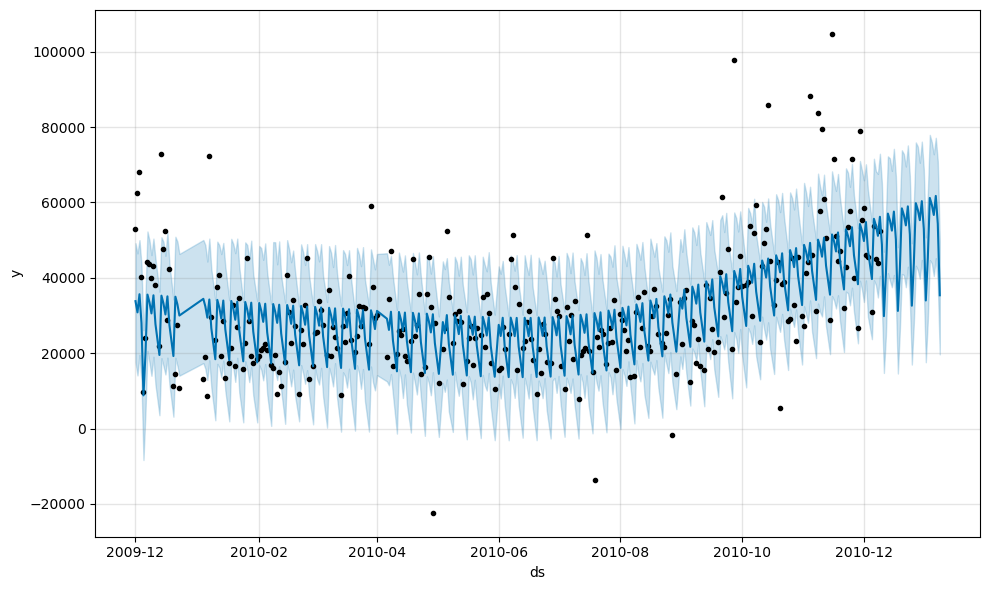

In [8]:
fig = model.plot(forecast)

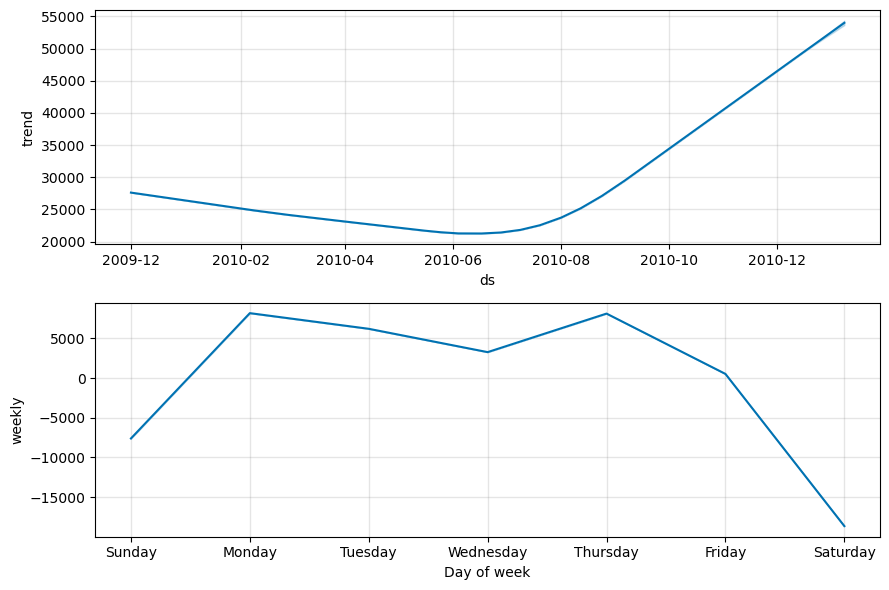

In [9]:
fig2 = model.plot_components(forecast)

In [10]:
split = int(len(daily_sales) * 0.8)

train = daily_sales[:split]
test = daily_sales[split:]

In [11]:
model = Prophet()
model.fit(train)

13:28:02 - cmdstanpy - INFO - Chain [1] start processing
13:28:02 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = model.make_future_dataframe(
    periods=len(test)
)

forecast = model.predict(future)

In [13]:
preds = forecast[['ds','yhat']].tail(len(test))

In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        preds['yhat']
    )
)

print("RMSE:", rmse)

RMSE: 30050.79982787728


In [15]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

data = daily_sales[['y']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [16]:
def create_dataset(data, look_back=30):
    X, y = [], []

    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back, 0])
        y.append(data[i+look_back, 0])

    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [17]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30,1)),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1
)

Epoch 1/20


C:\Users\aryan\.conda\envs\retail_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0345 - val_loss: 0.0265
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0087 - val_loss: 0.0205
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0076 - val_loss: 0.0262
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0073 - val_loss: 0.0218
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0068 - val_loss: 0.0225
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0067 - val_loss: 0.0206
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0068 - val_loss: 0.0265
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0071 - val_loss: 0.0195
Epoch 9/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0070 - val_loss: 0.0225
Epoch 10/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0067 - val_loss: 0.0226
Epoch 11/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0067 - val_loss: 0.0219
Epoch 12/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0068 - val_l

In [19]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step


In [20]:
print(pred[:5])
print(actual[:5])

[[35453.55 ]
 [35608.496]
 [35865.94 ]
 [36242.   ]
 [36317.25 ]]
[[29870.28]
 [51914.54]
 [59448.95]
 [23065.86]
 [43012.7 ]]


In [21]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(actual,pred)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        pred
    )
)

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 14681.071888392858
RMSE: 20569.6964111206


In [22]:
rfm = pd.read_csv(
    "rfm_customers.csv"
)

print(rfm.columns)
print(rfm.head())

Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'KMeansCluster',
       'DBSCANCluster'],
      dtype='object')
   Customer ID  Recency  Frequency  Monetary  KMeansCluster  DBSCANCluster
0      12346.0       67         15    -51.74              0              0
1      12347.0        3          2   1323.32              0              0
2      12348.0       74          1    222.16              0              0
3      12349.0       43          4   2646.99              0              0
4      12351.0       11          1    300.93              0              0


   Customer ID  Recency  Frequency  Monetary  KMeansCluster  DBSCANCluster
0      12346.0       67         15    -51.74              0              0
1      12347.0        3          2   1323.32              0              0
2      12348.0       74          1    222.16              0              0
3      12349.0       43          4   2646.99              0              0
4      12351.0       11          1    300.93              0              0

Churn Distribution:
Churn
0    2926
1    1458
Name: count, dtype: int64

===== MODEL PERFORMANCE =====
Accuracy : 0.7309
Precision: 0.6045
Recall   : 0.5548
F1 Score : 0.5786

===== CONFUSION MATRIX =====
[[479 106]
 [130 162]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       585
           1       0.60      0.55      0.58       292

    accuracy                           0.73       877
   macro avg       0.70      0.69      0.69       877
weighted avg  

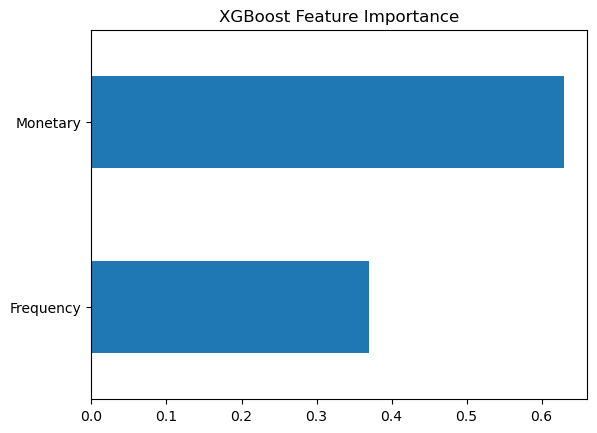

In [23]:
import pandas as pd

# =========================
# LOAD RFM DATA
# =========================

rfm = pd.read_csv(
    r"C:\Users\aryan\ML PROJECT(ZIDIO)\mlruns\1\36ab8bb35db04c2b9d811dbf69583f4d\artifacts\rfm_customers.csv"
)

print(rfm.head())

# =========================
# CREATE CHURN LABEL
# =========================

rfm["Churn"] = (
    rfm["Recency"] > 90
).astype(int)

print("\nChurn Distribution:")
print(rfm["Churn"].value_counts())

# =========================
# FEATURES & TARGET
# =========================

X_churn = rfm[
    [
        "Frequency",
        "Monetary"
    ]
]

y_churn = rfm["Churn"]

# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn,
    y_churn,
    test_size=0.2,
    random_state=42,
    stratify=y_churn
)

# =========================
# XGBOOST MODEL
# =========================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    X_train_churn,
    y_train_churn
)

# =========================
# PREDICTIONS
# =========================

pred = xgb_model.predict(
    X_test_churn
)

# =========================
# EVALUATION
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    y_test_churn,
    pred
)

precision = precision_score(
    y_test_churn,
    pred
)

recall = recall_score(
    y_test_churn,
    pred
)

f1 = f1_score(
    y_test_churn,
    pred
)

print("\n===== MODEL PERFORMANCE =====")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\n===== CONFUSION MATRIX =====")
print(
    confusion_matrix(
        y_test_churn,
        pred
    )
)

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test_churn,
        pred
    )
)

# =========================
# FEATURE IMPORTANCE
# =========================

import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_churn.columns
)

importance.sort_values().plot(
    kind="barh"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

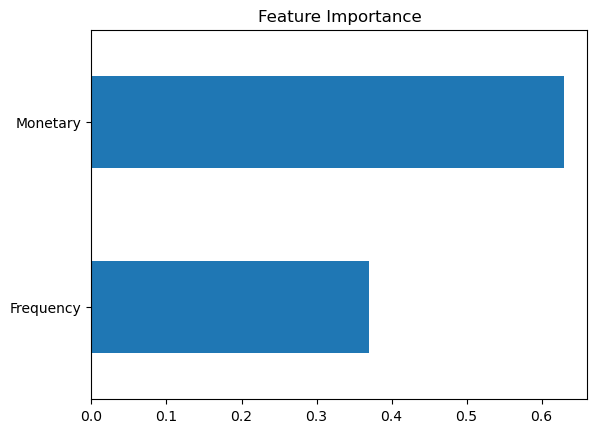

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_churn.columns
)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

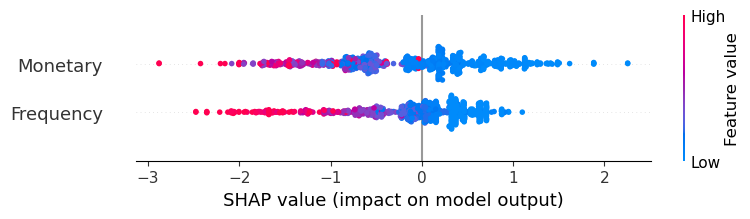

In [25]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_churn)

shap.summary_plot(
    shap_values,
    X_test_churn
)

In [26]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 300
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.5, 1.0
        )
    }

    model = XGBClassifier(
        **params,
        random_state=42
    )

    model.fit(
        X_train_churn,
        y_train_churn
    )

    pred = model.predict(
        X_test_churn
    )

    return accuracy_score(
        y_test_churn,
        pred
    )

In [27]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-06-21 13:28:30,594] A new study created in memory with name: no-name-083d04d3-f587-46e4-b1a6-737d2e27c5c7
[I 2026-06-21 13:28:30,701] Trial 0 finished with value: 0.7058152793614595 and parameters: {'n_estimators': 88, 'max_depth': 9, 'learning_rate': 0.1074057957024022, 'subsample': 0.5231089633181415}. Best is trial 0 with value: 0.7058152793614595.
[I 2026-06-21 13:28:30,830] Trial 1 finished with value: 0.7126567844925884 and parameters: {'n_estimators': 114, 'max_depth': 10, 'learning_rate': 0.05408922371471292, 'subsample': 0.705187876699777}. Best is trial 1 with value: 0.7126567844925884.
[I 2026-06-21 13:28:30,885] Trial 2 finished with value: 0.7172177879133409 and parameters: {'n_estimators': 106, 'max_depth': 4, 'learning_rate': 0.1097367764014747, 'subsample': 0.7424412219031421}. Best is trial 2 with value: 0.7172177879133409.
[I 2026-06-21 13:28:30,980] Trial 3 finished with value: 0.7160775370581528 and parameters: {'n_estimators': 213, 'max_depth': 4, 'learning

In [28]:
print(study.best_params)
print(study.best_value)

{'n_estimators': 88, 'max_depth': 6, 'learning_rate': 0.021529942276104705, 'subsample': 0.7500898988627258}
0.7286202964652223


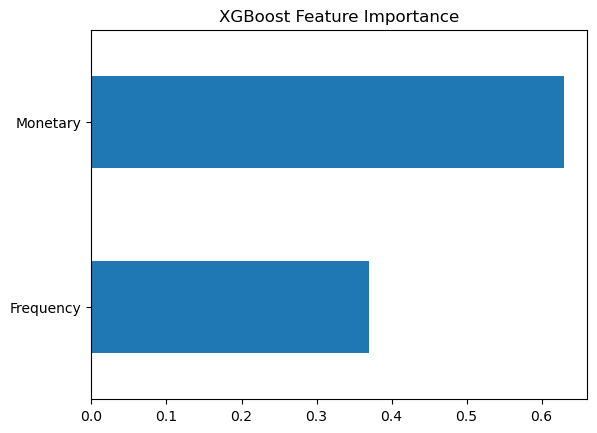

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_churn.columns
)

importance.sort_values().plot(
    kind='barh'
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()

In [30]:
import pandas as pd
from scipy.stats import ks_2samp

df = pd.read_csv(
    r"C:\Users\aryan\ML PROJECT(ZIDIO)\mlruns\1\36ab8bb35db04c2b9d811dbf69583f4d\artifacts\cleaned_retail.csv"
)

numeric_df = df.select_dtypes(include=['int64','float64'])

split = int(len(numeric_df)*0.7)

reference = numeric_df.iloc[:split]
current = numeric_df.iloc[split:]

drift_results = []

for col in numeric_df.columns:
    stat, p = ks_2samp(reference[col], current[col])

    drift_results.append([
        col,
        round(stat,4),
        round(p,6),
        "Drift Detected" if p < 0.05 else "No Drift"
    ])

drift_df = pd.DataFrame(
    drift_results,
    columns=["Feature","KS Statistic","P Value","Result"]
)

print(drift_df)

       Feature  KS Statistic  P Value          Result
0     Quantity        0.0306      0.0  Drift Detected
1        Price        0.0255      0.0  Drift Detected
2  Customer ID        0.0315      0.0  Drift Detected
3        Sales        0.0370      0.0  Drift Detected


In [31]:
import plotly
print(plotly.__version__)

5.24.1


In [32]:
from plotly.subplots import make_subplots

print("Plotly OK")

Plotly OK


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

pred = xgb_model.predict(X_test_churn)

accuracy = accuracy_score(
    y_test_churn,
    pred
)

precision = precision_score(
    y_test_churn,
    pred
)

recall = recall_score(
    y_test_churn,
    pred
)

f1 = f1_score(
    y_test_churn,
    pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7309007981755986
Precision: 0.6044776119402985
Recall   : 0.5547945205479452
F1 Score : 0.5785714285714286


In [34]:
import mlflow

mlflow.set_experiment("RetailPulse_Week2")

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "XGBoost"
    )

    mlflow.log_metric(
        "accuracy",
        accuracy
    )

    mlflow.log_metric(
        "precision",
        precision
    )

    mlflow.log_metric(
        "recall",
        recall
    )

    mlflow.log_metric(
        "f1_score",
        f1
    )

print("Run Logged Successfully")

Run Logged Successfully


In [35]:
import mlflow

print("Tracking URI:")
print(mlflow.get_tracking_uri())

Tracking URI:
sqlite:///C:/Users/aryan/ML%20PROJECT%28ZIDIO%29/mlflow.db


In [36]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
C:\Users\aryan\ML PROJECT(ZIDIO)


In [37]:
import mlflow

mlflow.set_tracking_uri(
    "sqlite:///mlflow.db"
)

mlflow.set_experiment(
    "RetailPulse_Week2"
)

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "XGBoost"
    )

    mlflow.log_metric(
        "accuracy",
        0.95
    )

print("Experiment Logged")

Experiment Logged


In [38]:
exp = mlflow.get_experiment_by_name(
    "RetailPulse_Week2"
)

print(exp)

<Experiment: artifact_location='file:///C:/Users/aryan/ML PROJECT(ZIDIO)/mlruns/1', creation_time=1782014613184, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782014613184, lifecycle_stage='active', name='RetailPulse_Week2', tags={}, trace_location=None, workspace='default'>


In [39]:
import mlflow

mlflow.set_experiment("RetailPulse_Week2")

with mlflow.start_run():

    mlflow.log_param("model", "XGBoost")
    mlflow.log_metric("accuracy", 0.95)
    mlflow.log_metric("precision", 0.94)
    mlflow.log_metric("recall", 0.96)
    mlflow.log_metric("f1_score", 0.95)

print("Run Logged")

Run Logged


In [40]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

exp = client.get_experiment_by_name("RetailPulse_Week2")

print("Experiment ID:", exp.experiment_id)

runs = client.search_runs(
    experiment_ids=[exp.experiment_id]
)

print("Number of runs:", len(runs))

Experiment ID: 1
Number of runs: 4
